In [14]:
# calculate per-unit AUC for each session (all units)

import numpy as np
from pathlib import Path

from calculate_auc import per_unit_auc_from_psth
from create_psth import load_zarr
from general_utils import smart_read_csv, find_ephys_sessions

# ---------------------------------------------------------------------
# User parameters
# ---------------------------------------------------------------------
binsize = "0.2"
align = "go_cue"

# Time windows over which to average PSTH for per-unit AUC
time_windows = [[0.3, 2], [-1, 0]]

# Trial types used for defining class A and class B
trial_types = ["right_choice_trials", "left_choice_trials"]
trial_types = ["rewarded_trials", "unrewarded_trials"]

# AUC-related parameters
n_trials_per_class = 100   # None => use min(nA, nB); or set an int like 15
n_repeats = 100
min_trials_per_class = 8
random_state = 0

psth_root = Path("/root/capsule/scratch/psth_results")
behavior_root = Path("/root/capsule/scratch/behavior_summary")
auc_root = Path("/root/capsule/scratch/AUC_results")
auc_root.mkdir(parents=True, exist_ok=True)

# Metadata
metadata_path = Path("/root/capsule/scratch/qc_passed_units_metadata_all_sessions.csv")
metadata = smart_read_csv(metadata_path)

# ---------------------------------------------------------------------
# Helpers
# ---------------------------------------------------------------------
def _clean_ids(x):
    """
    Convert behavior_summary column (x) into an integer array of trial IDs.
    Assumes x[0] contains the list/array of trial IDs.
    """
    arr = np.asarray(x[0])
    if arr.dtype.kind in {"f"}:  # float -> may contain NaN
        arr = arr[~np.isnan(arr)]
    return arr.astype(int)


# ---------------------------------------------------------------------
# Main loop
# ---------------------------------------------------------------------
sessions = find_ephys_sessions()
failed_sessions_auc = []

print("Total sessions (index 2):", len(sessions[2]))

for session in sessions[2]:
    print("\n==============================")
    print(f"Session: {session}")
    print("==============================")

    try:
        # The metadata uses “sorted_session_name”
        sorted_session_name = session

        psth_path = psth_root / f"{session}_{binsize}s.zarr"
        behavior_path = behavior_root / f"behavior_summary-{session}.csv"

        psth_da = load_zarr(str(psth_path))
        df = smart_read_csv(str(behavior_path))

        # Pull trial-id arrays and clean up
        typeA_ids = _clean_ids(df[trial_types[0]])
        typeB_ids = _clean_ids(df[trial_types[1]])

        print(f"  {trial_types[0]}: {len(typeA_ids)} trials")
        print(f"  {trial_types[1]}: {len(typeB_ids)} trials")

        # -------------------------------------------------------------
        # Loop over time windows for AUC calculation (all units)
        # -------------------------------------------------------------
        for time_window in time_windows:
            tw0, tw1 = time_window

            save_path = (
                auc_root
                / f"AUC_{session}_{trial_types[0]}_{trial_types[1]}_TW_{tw0}_{tw1}.zarr"
            )

            try:
                res = per_unit_auc_from_psth(
                    psth_da=psth_da,
                    trial_ids_typeA=typeA_ids,
                    trial_ids_typeB=typeB_ids,
                    align=align,
                    time_window=tuple(time_window),
                    n_trials_per_class=n_trials_per_class,
                    n_repeats=n_repeats,
                    min_trials_per_class=min_trials_per_class,
                    random_state=random_state,
                    unit_ids=None,            # all units
                    metadata=metadata,        # >>> ADDED
                    sorted_session_name=sorted_session_name,   # >>> ADDED
                    metadata_unit_col="unit_index",            # >>> ADDED
                    save_path=str(save_path),
                    save_format="zarr",
                    overwrite=True,
                )

                if res.get("skipped", False):
                    print(
                        f"    Skip time window {time_window}: "
                        f"{res.get('reason', 'no reason provided')}"
                    )
                else:
                    print(
                        f"    ✔ Finished AUC time window {time_window}: "
                        f"{res.get('saved_to', str(save_path))}"
                    )

            except Exception as e:
                print(f"    ❌ Error in AUC time window {time_window}: {e}")
                failed_sessions_auc.append(
                    (session, f"time_window={time_window}", str(e))
                )

    except Exception as e:
        print(f"❌ ERROR loading session {session}: {e}")
        failed_sessions_auc.append((session, "load_failure", str(e)))


print("\n==============================")
print("All AUC calculations done (all units).")
print("==============================")
if failed_sessions_auc:
    print("Failed items:")
    for f in failed_sessions_auc:
        print(" -", f)
else:
    print("No errors")


Total sessions (index 2): 41

Session: ecephys_753124_2024-12-10_17-24-56_sorted_2024-12-13_09-48-25
  rewarded_trials: 142 trials
  unrewarded_trials: 218 trials
    ✔ Finished AUC time window [0.3, 2]: /root/capsule/scratch/AUC_results/AUC_ecephys_753124_2024-12-10_17-24-56_sorted_2024-12-13_09-48-25_rewarded_trials_unrewarded_trials_TW_0.3_2.zarr
    ✔ Finished AUC time window [-1, 0]: /root/capsule/scratch/AUC_results/AUC_ecephys_753124_2024-12-10_17-24-56_sorted_2024-12-13_09-48-25_rewarded_trials_unrewarded_trials_TW_-1_0.zarr

Session: ecephys_753125_2024-10-09_10-50-19_sorted_2024-11-09_20-03-58
  rewarded_trials: 299 trials
  unrewarded_trials: 256 trials
    ✔ Finished AUC time window [0.3, 2]: /root/capsule/scratch/AUC_results/AUC_ecephys_753125_2024-10-09_10-50-19_sorted_2024-11-09_20-03-58_rewarded_trials_unrewarded_trials_TW_0.3_2.zarr
    ✔ Finished AUC time window [-1, 0]: /root/capsule/scratch/AUC_results/AUC_ecephys_753125_2024-10-09_10-50-19_sorted_2024-11-09_20-03-5

In [15]:
from pathlib import Path
from calculate_auc import auto_combine_all_auc_patterns

combined_map = auto_combine_all_auc_patterns(
    root_dir=Path("/root/capsule/scratch/AUC_results"),
    overwrite=False,   # set True if you want to regenerate combined files
)

combined_map



Detected patterns:
  Pattern: rewarded_trials_unrewarded_trials_TW_-1_0.zarr  (n_files=38)
  Pattern: rewarded_trials_unrewarded_trials_TW_0.3_2.zarr  (n_files=38)
  Pattern: right_choice_trials_left_choice_trials_TW_-1_0.zarr  (n_files=38)
  Pattern: right_choice_trials_left_choice_trials_TW_0.3_2.zarr  (n_files=38)

=== Combining pattern: rewarded_trials_unrewarded_trials_TW_-1_0.zarr ===
  Files (38):
    - AUC_ecephys_753124_2024-12-10_17-24-56_sorted_2024-12-13_09-48-25_rewarded_trials_unrewarded_trials_TW_-1_0.zarr
    - AUC_ecephys_753125_2024-10-09_10-50-19_sorted_2024-11-09_20-03-58_rewarded_trials_unrewarded_trials_TW_-1_0.zarr
    - AUC_ecephys_753125_2024-10-10_14-41-23_sorted_2024-11-09_20-18-36_rewarded_trials_unrewarded_trials_TW_-1_0.zarr
    - AUC_ecephys_753125_2024-10-14_15-37-15_sorted_2024-11-09_20-07-38_rewarded_trials_unrewarded_trials_TW_-1_0.zarr
    - AUC_ecephys_753125_2024-10-15_16-16-22_sorted_2024-11-09_19-57-50_rewarded_trials_unrewarded_trials_TW_-1_0.z

{'rewarded_trials_unrewarded_trials_TW_-1_0.zarr': PosixPath('/root/capsule/scratch/AUC_results/AUC_combined_rewarded_trials_unrewarded_trials_TW_-1_0_by_unit.zarr'),
 'rewarded_trials_unrewarded_trials_TW_0.3_2.zarr': PosixPath('/root/capsule/scratch/AUC_results/AUC_combined_rewarded_trials_unrewarded_trials_TW_0.3_2_by_unit.zarr'),
 'right_choice_trials_left_choice_trials_TW_-1_0.zarr': PosixPath('/root/capsule/scratch/AUC_results/AUC_combined_right_choice_trials_left_choice_trials_TW_-1_0_by_unit.zarr'),
 'right_choice_trials_left_choice_trials_TW_0.3_2.zarr': PosixPath('/root/capsule/scratch/AUC_results/AUC_combined_right_choice_trials_left_choice_trials_TW_0.3_2_by_unit.zarr')}

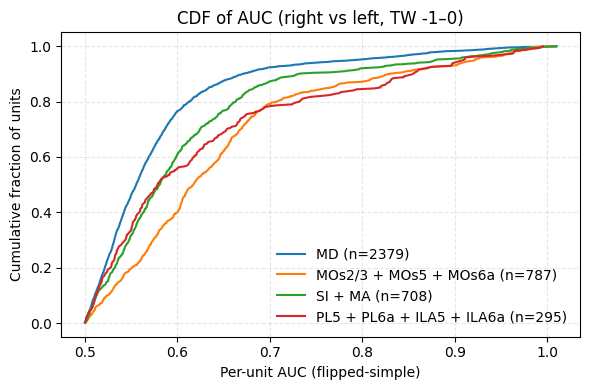

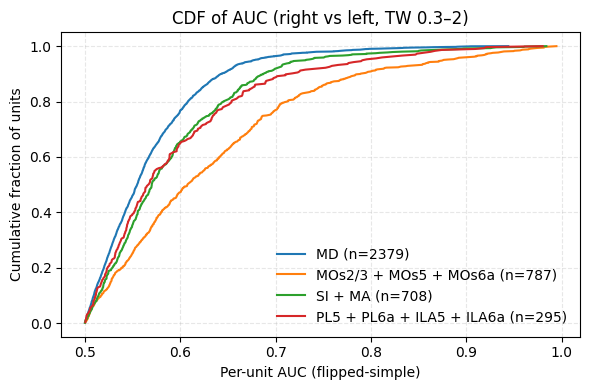

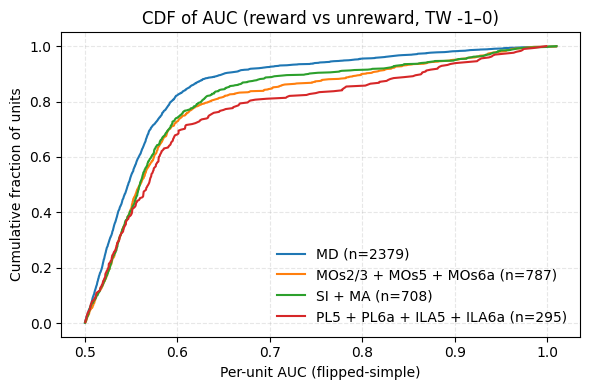

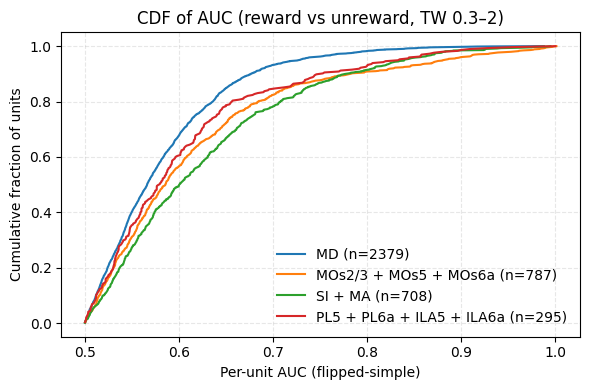

In [18]:
from pathlib import Path
from calculate_auc_visualization import plot_auc_cdf_by_region

combined_path = Path("/root/capsule/scratch/AUC_results") / \
    "AUC_combined_right_choice_trials_left_choice_trials_TW_-1_0_by_unit.zarr"
fig, ax, counts = plot_auc_cdf_by_region(
    combined_path,
    auc_var="auc_mean",
    region_var="meta_brain_region",
    brain_regions=[["MD"], ["MOs2/3","MOs5","MOs6a"],['SI','MA'],["PL5","PL6a","ILA5","ILA6a"]],     # NEW
    min_units_per_region=20,
    title="CDF of AUC (right vs left, TW -1–0)",
    flip_auc=True,
    flip_mode='simple'

)


combined_path = Path("/root/capsule/scratch/AUC_results") / \
    "AUC_combined_right_choice_trials_left_choice_trials_TW_0.3_2_by_unit.zarr"

fig, ax, counts = plot_auc_cdf_by_region(
    combined_path,
    auc_var="auc_mean",
    region_var="meta_brain_region",
    brain_regions=[["MD"], ["MOs2/3","MOs5","MOs6a"],['SI','MA'],["PL5","PL6a","ILA5","ILA6a"]],     # NEW
    min_units_per_region=20,
    title="CDF of AUC (right vs left, TW 0.3–2)",
    flip_auc=True,
    flip_mode='simple'

)



combined_path = Path("/root/capsule/scratch/AUC_results") / \
    "AUC_combined_rewarded_trials_unrewarded_trials_TW_-1_0_by_unit.zarr"
fig, ax, counts = plot_auc_cdf_by_region(
    combined_path,
    auc_var="auc_mean",
    region_var="meta_brain_region",
    brain_regions=[["MD"], ["MOs2/3","MOs5","MOs6a"],['SI','MA'],["PL5","PL6a","ILA5","ILA6a"]],     # NEW
    min_units_per_region=20,
    title="CDF of AUC (reward vs unreward, TW -1–0)",
    flip_auc=True,
    flip_mode='simple'

)


combined_path = Path("/root/capsule/scratch/AUC_results") / \
    "AUC_combined_rewarded_trials_unrewarded_trials_TW_0.3_2_by_unit.zarr"

fig, ax, counts = plot_auc_cdf_by_region(
    combined_path,
    auc_var="auc_mean",
    region_var="meta_brain_region",
    brain_regions=[["MD"], ["MOs2/3","MOs5","MOs6a"],['SI','MA'],["PL5","PL6a","ILA5","ILA6a"]],     # NEW
    min_units_per_region=20,
    title="CDF of AUC (reward vs unreward, TW 0.3–2)",
    flip_auc=True,
    flip_mode='simple'

)


